## Run results 

In [1]:
import pennylane as qml
import qutip as qt
from qutip import *  

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline 

In [2]:
N = 3
dt = 0.02
# dt = 0.01
mf = 10
ntraj = 90000

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

k = 45

r_now_open_arr = []
r_kasf1_arr = []

succ_prob_now_open_arr = []
succ_prob_kasf1_arr = []

beta_now_open_arr = []
beta_kasf1_arr = []

for seed in range(3,4):

    file_path = f'data_appendix/r_N_{N}_mf_{mf}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
    agp_arr = np.load(file_path)
    r_now_open, r_kasf1, r1_now = agp_arr[0], agp_arr[1], agp_arr[2]
    r_now_open_arr.append(r_now_open)
    r_kasf1_arr.append(r_kasf1)

    file_path = f'data_appendix/beta_N_{N}_mf_{mf}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
    agp_arr2 = np.load(file_path)
    beta_now_open, beta_kasf1, beta1_now = agp_arr2[0], agp_arr2[1], agp_arr2[2]
    beta_now_open_arr.append(beta_now_open)
    beta_kasf1_arr.append(beta_kasf1)

    file_path = f'data_appendix/phi_N_{N}_mf_{mf}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
    agp_arr3 = np.load(file_path)
    succ_prob_now_open, succ_prob_kasf1, succ_prob1_now = agp_arr3[0], agp_arr3[1], agp_arr3[2]
    succ_prob_now_open_arr.append(succ_prob_now_open)
    succ_prob_kasf1_arr.append(succ_prob_kasf1)

g0 = []
g1 = []
g2 = []
g3 = []
g4 = []

klm = 97

for seed in range(3,4):
    # if seed != 6:
        file_path = f'data_appendix/gamma_N_{N}_mf_{mf}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
        gammv = np.load(file_path)

        file_path = f'data_appendix/trace_N_{N}_mf_{mf}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
        trace_val = np.load(file_path)

        g00, g11, g22, g33, g44 = gammv[0], gammv[1], gammv[2], gammv[3], gammv[4]


        g0.append(g00[1:klm])
        g1.append(g11[1:klm])
        g2.append(g22[1:klm])
        g3.append(g33[1:klm])
        g4.append(g44[1:klm])


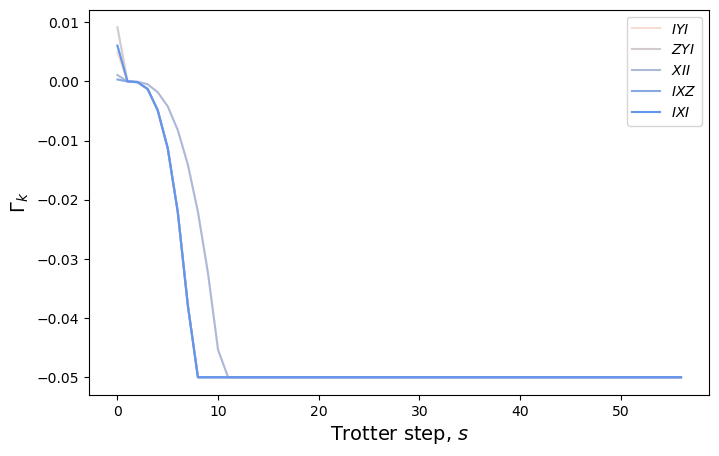

In [4]:
import matplotlib.colors as mcolors  # Needed for color conversion

array_g0 = np.column_stack(g0)
array_g1 = np.column_stack(g1)
array_g2 = np.column_stack(g2)
array_g3 = np.column_stack(g3)
array_g4 = np.column_stack(g4)

Norm_factor = 1/np.sqrt(N)

mean_values_g0 = np.mean(array_g0, axis=1)
std_values_g0 = np.std(array_g0, axis=1)

mean_values_g1 = np.mean(array_g1, axis=1)
std_values_g1 = np.std(array_g1, axis=1)

mean_values_g2 = np.mean(array_g2, axis=1)
std_values_g2 = np.std(array_g2, axis=1)

mean_values_g3 = np.mean(array_g3, axis=1)
std_values_g3 = np.std(array_g3, axis=1)

mean_values_g4 = np.mean(array_g4, axis=1)
std_values_g4 = np.std(array_g4, axis=1)


# X-axis indices
x = np.arange(len(mean_values_g0))

# colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231'] 
colors = ['#6495ED', '#89A7E2', '#AEB9D7', '#D3CBCC', '#F8DED1', '#F6BDC0']

green_rgb = np.array(mcolors.to_rgb('g'))   # green as [0.0, 0.5, 0.0]
magenta_rgb = np.array(mcolors.to_rgb('m'))

# Generate 5 colors interpolating between green and magenta
# colors = [green_rgb + (magenta_rgb - green_rgb) * i/4 for i in range(5)]

# colors = ['blue', 'orange', 'g', 'purple', 'olive']



# Plot mean with standard deviation
plt.figure(figsize=(8, 5))
plt.plot(x, mean_values_g0, label=r"$IYI$", color=colors[4])
plt.fill_between(x, mean_values_g0 - std_values_g0*Norm_factor, mean_values_g0 + std_values_g0 * Norm_factor, color=colors[4], alpha=0.2)

plt.plot(x, mean_values_g1, label=r"$ZYI$", color=colors[3])
plt.fill_between(x, mean_values_g1 - std_values_g1 * Norm_factor, mean_values_g1 + std_values_g1 * Norm_factor, color=colors[3], alpha=0.2)

plt.plot(x, mean_values_g2, label=r"$XII$", color=colors[2])
plt.fill_between(x, mean_values_g2 - std_values_g2 * Norm_factor, mean_values_g2 + std_values_g2 * Norm_factor,color=colors[2], alpha=0.2)

plt.plot(x, mean_values_g3, label=r"$IXZ$", color=colors[1])
plt.fill_between(x, mean_values_g3 - std_values_g3 * Norm_factor, mean_values_g3 + std_values_g3 * Norm_factor,color=colors[1], alpha=0.2)

plt.plot(x, mean_values_g4, label=r"$IXI$", color=colors[0])
plt.fill_between(x, mean_values_g4 - std_values_g4 * Norm_factor, mean_values_g4 + std_values_g4 * Norm_factor, color=colors[0], alpha=0.2)


# Labels and legend
plt.xlabel(r"Trotter step, $s$", fontsize=14)
plt.ylabel(r"$\Gamma_k$", fontsize=14)
plt.legend()
# plt.title("Mean with Standard Deviation (Column-wise)")

# filename = f"demo_2.pdf"  # Creates "plot_experiment1.png"
# plt.savefig(filename)

plt.show()

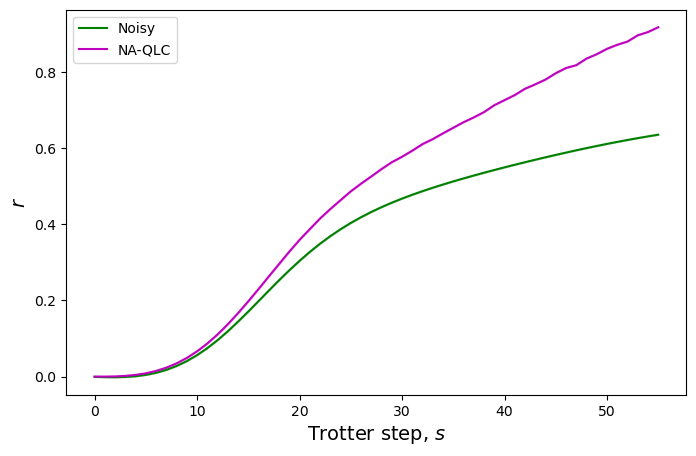

In [5]:
array_r_noisy = np.column_stack(r_now_open_arr)
array_r_naqlc = np.column_stack(r_kasf1_arr)
Norm_factor = 1/np.sqrt(N)

mean_values_r_noisy = np.mean(array_r_noisy, axis=1)
std_values_r_noisy = np.std(array_r_noisy, axis=1)

mean_values_r_naqlc = np.mean(array_r_naqlc, axis=1)
std_values_r_naqlc = np.std(array_r_naqlc, axis=1)


# X-axis indices
x = np.arange(len(mean_values_r_noisy))

# Plot mean with standard deviation
plt.figure(figsize=(8, 5))
plt.plot(x, mean_values_r_noisy, label="Noisy", color="g")
plt.fill_between(x, mean_values_r_noisy - std_values_r_noisy*Norm_factor, mean_values_r_noisy + std_values_r_noisy*Norm_factor, color='g', alpha=0.2)

plt.plot(x, mean_values_r_naqlc, label="NA-QLC", color="m")
plt.fill_between(x, mean_values_r_naqlc - std_values_r_naqlc * Norm_factor, mean_values_r_naqlc + std_values_r_naqlc * Norm_factor, color='m', alpha=0.2)

# Labels and legend
plt.xlabel(r"Trotter step, $s$", fontsize=14)
plt.ylabel(r"$r$", fontsize=14)
# plt.title("Mean with Standard Deviation (Column-wise)")
plt.legend()
plt.show()

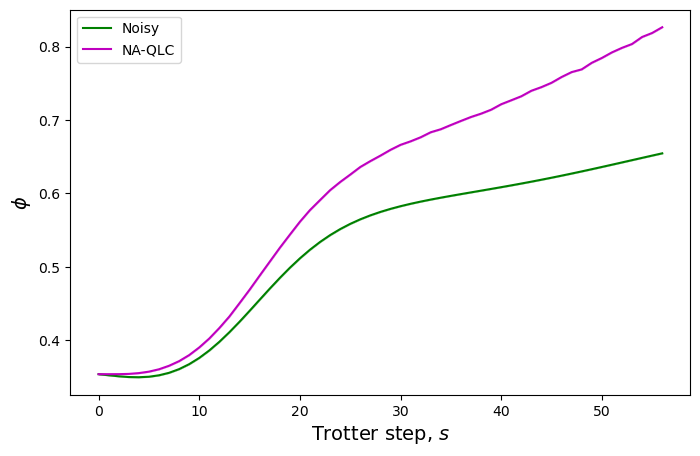

In [6]:
array_phi_noisy = np.column_stack(succ_prob_now_open_arr) 
array_phi_naqlc = np.column_stack(succ_prob_kasf1_arr)
Norm_factor = 1/np.sqrt(N)

mean_values_phi_noisy = np.mean(array_phi_noisy, axis=1)
std_values_phi_noisy = np.std(array_phi_noisy, axis=1)

mean_values_phi_naqlc = np.mean(array_phi_naqlc, axis=1)
std_values_phi_naqlc = np.std(array_phi_naqlc, axis=1)


# X-axis indices
x = np.arange(len(mean_values_phi_noisy))

# Plot mean with standard deviation
plt.figure(figsize=(8, 5))
plt.plot(x, mean_values_phi_noisy, label="Noisy", color="g")
plt.fill_between(x, mean_values_phi_noisy - std_values_phi_noisy * Norm_factor, mean_values_phi_noisy + std_values_phi_noisy * Norm_factor, color='g', alpha=0.2)

plt.plot(x, mean_values_phi_naqlc, label="NA-QLC", color="m")
plt.fill_between(x, mean_values_phi_naqlc - std_values_phi_naqlc * Norm_factor, mean_values_phi_naqlc + std_values_phi_naqlc * Norm_factor, color='m', alpha=0.2)

# plt.plot([1]*26,linestyle='--', linewidth=2, color = 'black')

# Labels and legend
plt.xlabel(r"Trotter step, $s$", fontsize=14)
plt.ylabel(r"$\phi$",fontsize=14)
# plt.title("Mean with Standard Deviation (Column-wise)")
plt.legend()
plt.show()

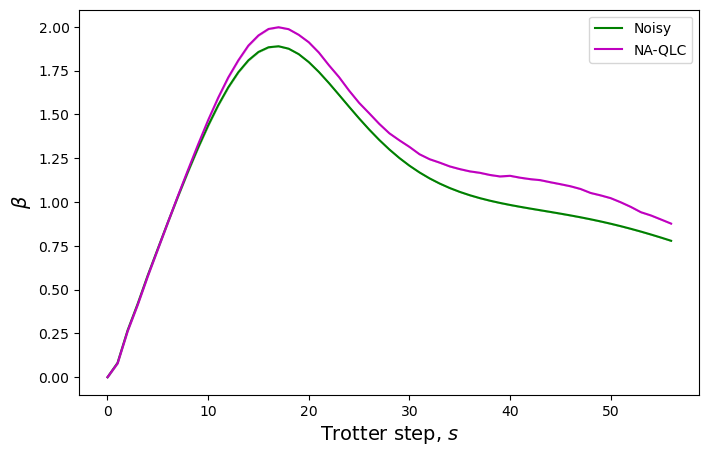

In [7]:
array_beta_noisy = np.column_stack(beta_now_open_arr) 
array_beta_naqlc = np.column_stack(beta_kasf1_arr)
Norm_factor = 1/np.sqrt(N)

mean_values_beta_noisy = np.mean(array_beta_noisy, axis=1)
std_values_beta_noisy = np.std(array_beta_noisy, axis=1)

mean_values_beta_naqlc = np.mean(array_beta_naqlc, axis=1)
std_values_beta_naqlc = np.std(array_beta_naqlc, axis=1)


# X-axis indices
x = np.arange(len(mean_values_beta_noisy))

# Plot mean with standard deviation
plt.figure(figsize=(8, 5))
plt.plot(x, mean_values_beta_noisy, label="Noisy", color="g")
plt.fill_between(x, mean_values_beta_noisy - std_values_beta_noisy * Norm_factor, mean_values_beta_noisy + std_values_beta_noisy * Norm_factor, color='g', alpha=0.2)

plt.plot(x, mean_values_beta_naqlc, label="NA-QLC", color="m")
plt.fill_between(x, mean_values_beta_naqlc - std_values_beta_naqlc * Norm_factor, mean_values_beta_naqlc + std_values_beta_naqlc * Norm_factor, color='m', alpha=0.2)


# Labels and legend
plt.xlabel(r"Trotter step, $s$", fontsize=14)
plt.ylabel(r"$\beta$",fontsize=14)
# plt.title("Mean with Standard Deviation (Column-wise)")
plt.legend()
plt.show()

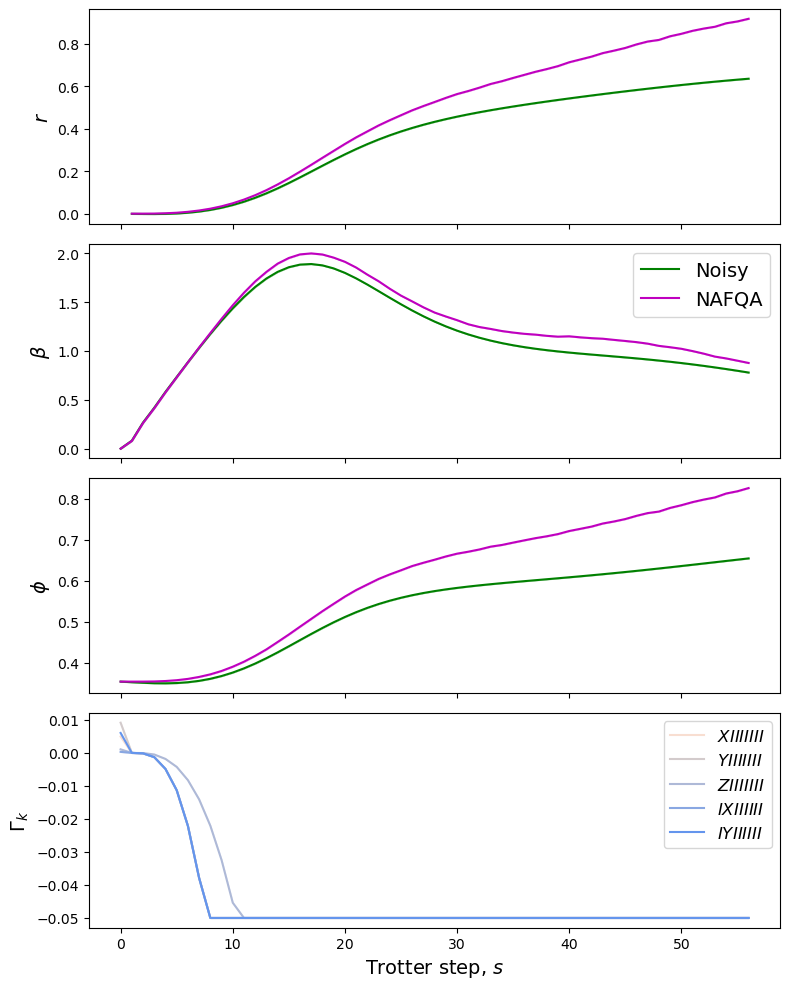

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

x = np.arange(1, len(mean_values_r_noisy)+1)
axes[0].plot(x, mean_values_r_noisy, label="Noisy", color="g")
axes[0].fill_between(x, mean_values_r_noisy - std_values_r_noisy*Norm_factor, mean_values_r_noisy + std_values_r_noisy*Norm_factor, color='g', alpha=0.2)
axes[0].plot(x, mean_values_r_naqlc, label="NA-QLC", color="m")
axes[0].fill_between(x, mean_values_r_naqlc - std_values_r_naqlc * Norm_factor, mean_values_r_naqlc + std_values_r_naqlc * Norm_factor, color='m', alpha=0.2)
# axes[0].plot([1]*26,linestyle='--', linewidth=2, color = 'black')
axes[0].set_ylabel(r"$r$", fontsize=14)
# axes[0].text(1.2, 0.77, "(a)", fontsize=12, fontweight='bold')


x = np.arange(len(mean_values_beta_noisy))
axes[1].plot(x, mean_values_beta_noisy, label="Noisy", color="g")
axes[1].fill_between(x, mean_values_beta_noisy - std_values_beta_noisy * Norm_factor, mean_values_beta_noisy + std_values_beta_noisy * Norm_factor, color='g', alpha=0.2)
axes[1].plot(x, mean_values_beta_naqlc, label="NAFQA", color="m")
axes[1].fill_between(x, mean_values_beta_naqlc - std_values_beta_naqlc * Norm_factor, mean_values_beta_naqlc + std_values_beta_naqlc * Norm_factor, color='m', alpha=0.2)
# axes[1].plot([1]*26,linestyle='--', linewidth=2, color = 'black')
axes[1].set_ylabel(r"$\beta$",fontsize=14)
# axes[1].set_xlabel(r"Trotter step, $s$", fontsize=12)
# axes[1].text(1.2, 2.25, "(b)", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=14)


x = np.arange(len(mean_values_phi_noisy))
axes[2].plot(x, mean_values_phi_noisy, label="Noisy", color="g")
axes[2].fill_between(x, mean_values_phi_noisy - std_values_phi_noisy * Norm_factor, mean_values_phi_noisy + std_values_phi_noisy * Norm_factor, color='g', alpha=0.2)
axes[2].plot(x, mean_values_phi_naqlc, label="NA-FQA", color="m")
axes[2].fill_between(x, mean_values_phi_naqlc - std_values_phi_naqlc * Norm_factor, mean_values_phi_naqlc + std_values_phi_naqlc * Norm_factor, color='m', alpha=0.2)
# axes[2].plot([1]*26,linestyle='--', linewidth=2, color = 'black')
axes[2].set_ylabel(r"$\phi$",fontsize=14)
# axes[2].set_xlabel(r"Trotter step, $s$", fontsize=14)
# axes[2].text(1.2, 0.52, "(c)", fontsize=12, fontweight='bold')


x = np.arange(len(mean_values_g0))

colors = ['#6495ED', '#89A7E2', '#AEB9D7', '#D3CBCC', '#F8DED1', '#F6BDC0']

# Plot mean with standard deviation
axes[3].plot(x, mean_values_g0, label=r"$XIIIIIII$", color=colors[4])
axes[3].fill_between(x, mean_values_g0 - std_values_g0*Norm_factor, mean_values_g0 + std_values_g0 * Norm_factor, color=colors[4], alpha=0.15)

axes[3].plot(x, mean_values_g1, label=r"$YIIIIIII$", color=colors[3])
axes[3].fill_between(x, mean_values_g1 - std_values_g1 * Norm_factor, mean_values_g1 + std_values_g1 * Norm_factor, color=colors[3], alpha=0.15)

axes[3].plot(x, mean_values_g2, label=r"$ZIIIIIII$", color=colors[2])
axes[3].fill_between(x, mean_values_g2 - std_values_g2 * Norm_factor, mean_values_g2 + std_values_g2 * Norm_factor,color=colors[2], alpha=0.15)

axes[3].plot(x, mean_values_g3, label=r"$IXIIIIII$", color=colors[1])
axes[3].fill_between(x, mean_values_g3 - std_values_g3 * Norm_factor, mean_values_g3 + std_values_g3 * Norm_factor,color=colors[1], alpha=0.15)

axes[3].plot(x[0:95], mean_values_g4[0:95], label=r"$IYIIIIII$", color=colors[0])
axes[3].fill_between(x, mean_values_g4 - std_values_g4 * Norm_factor, mean_values_g4 + std_values_g4 * Norm_factor, color=colors[0], alpha=0.15)
axes[3].legend(fontsize=12)
axes[3].set_ylabel(r"$\Gamma_k$",fontsize=14)
axes[3].set_xlabel(r"Trotter step, $s$", fontsize=14)
# axes[3].text(.8, 0.04, "(d)", fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()
# filename = f"TFIM_N8.pdf"  # Creates "plot_experiment1.png"
# plt.savefig(filename)
plt.show()


## Other results

In [9]:
N = 3
dt = 0.02
# dt = 0.01
mf = 10
ntraj = 90000

In [57]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
k = 45
seeds = [1, 3, 4, 5, 8, 9, 11, 12, 15, 16]
# seeds = [13]

# file_path = f'data_5q/gamma_mf_{mf}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
# gammv = np.load(file_path)


r_now_open_arr = []
r_kasf1_arr = []

succ_prob_now_open_arr = []
succ_prob_kasf1_arr = []

beta_now_open_arr = []
beta_kasf1_arr = []

th = 0.05

for seed in seeds:

    file_path = f'data_appendix/r_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
    agp_arr = np.load(file_path)
    r_now_open, r_kasf1, r1_now = agp_arr[0], agp_arr[1], agp_arr[2]
    r_now_open_arr.append(r_now_open)
    r_kasf1_arr.append(r_kasf1)

    file_path = f'data_appendix/beta_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
    agp_arr2 = np.load(file_path)
    beta_now_open, beta_kasf1, beta1_now = agp_arr2[0], agp_arr2[1], agp_arr2[2]
    beta_now_open_arr.append(beta_now_open)
    beta_kasf1_arr.append(beta_kasf1)

    file_path = f'data_appendix/phi_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
    agp_arr3 = np.load(file_path)
    succ_prob_now_open, succ_prob_kasf1, succ_prob1_now = agp_arr3[0], agp_arr3[1], agp_arr3[2]
    succ_prob_now_open_arr.append(succ_prob_now_open)
    succ_prob_kasf1_arr.append(succ_prob_kasf1)

g0 = []
g1 = []
g2 = []
g3 = []
g4 = []

klm = 97

for seed in seeds:
    # if seed != 6:
        file_path = f'data_appendix/gamma_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
        gammv = np.load(file_path)

        file_path = f'data_appendix/trace_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
        trace_val = np.load(file_path)

        g00, g11, g22, g33, g44 = gammv[0], gammv[1], gammv[2], gammv[3], gammv[4]


        g0.append(g00[1:klm])
        g1.append(g11[1:klm])
        g2.append(g22[1:klm])
        g3.append(g33[1:klm])
        g4.append(g44[1:klm])


In [58]:
import matplotlib.colors as mcolors  # Needed for color conversion

array_g0 = np.column_stack(g0)
array_g1 = np.column_stack(g1)
array_g2 = np.column_stack(g2)
array_g3 = np.column_stack(g3)
array_g4 = np.column_stack(g4)

Norm_factor = 1/np.sqrt(N)

mean_values_g0 = np.mean(array_g0, axis=1)
std_values_g0 = np.std(array_g0, axis=1)

mean_values_g1 = np.mean(array_g1, axis=1)
std_values_g1 = np.std(array_g1, axis=1)

mean_values_g2 = np.mean(array_g2, axis=1)
std_values_g2 = np.std(array_g2, axis=1)

mean_values_g3 = np.mean(array_g3, axis=1)
std_values_g3 = np.std(array_g3, axis=1)

mean_values_g4 = np.mean(array_g4, axis=1)
std_values_g4 = np.std(array_g4, axis=1)

array_r_noisy = np.column_stack(r_now_open_arr)
array_r_naqlc = np.column_stack(r_kasf1_arr)
Norm_factor = 1/np.sqrt(N)

mean_values_r_noisy = np.mean(array_r_noisy, axis=1)
std_values_r_noisy = np.std(array_r_noisy, axis=1)

mean_values_r_naqlc = np.mean(array_r_naqlc, axis=1)
std_values_r_naqlc = np.std(array_r_naqlc, axis=1)

array_phi_noisy = np.column_stack(succ_prob_now_open_arr) 
array_phi_naqlc = np.column_stack(succ_prob_kasf1_arr)
Norm_factor = 1/np.sqrt(N)

mean_values_phi_noisy = np.mean(array_phi_noisy, axis=1)
std_values_phi_noisy = np.std(array_phi_noisy, axis=1)

mean_values_phi_naqlc = np.mean(array_phi_naqlc, axis=1)
std_values_phi_naqlc = np.std(array_phi_naqlc, axis=1)

array_beta_noisy = np.column_stack(beta_now_open_arr) 
array_beta_naqlc = np.column_stack(beta_kasf1_arr)
Norm_factor = 1/np.sqrt(N)

mean_values_beta_noisy = np.mean(array_beta_noisy, axis=1)
std_values_beta_noisy = np.std(array_beta_noisy, axis=1)

mean_values_beta_naqlc = np.mean(array_beta_naqlc, axis=1)
std_values_beta_naqlc = np.std(array_beta_naqlc, axis=1)



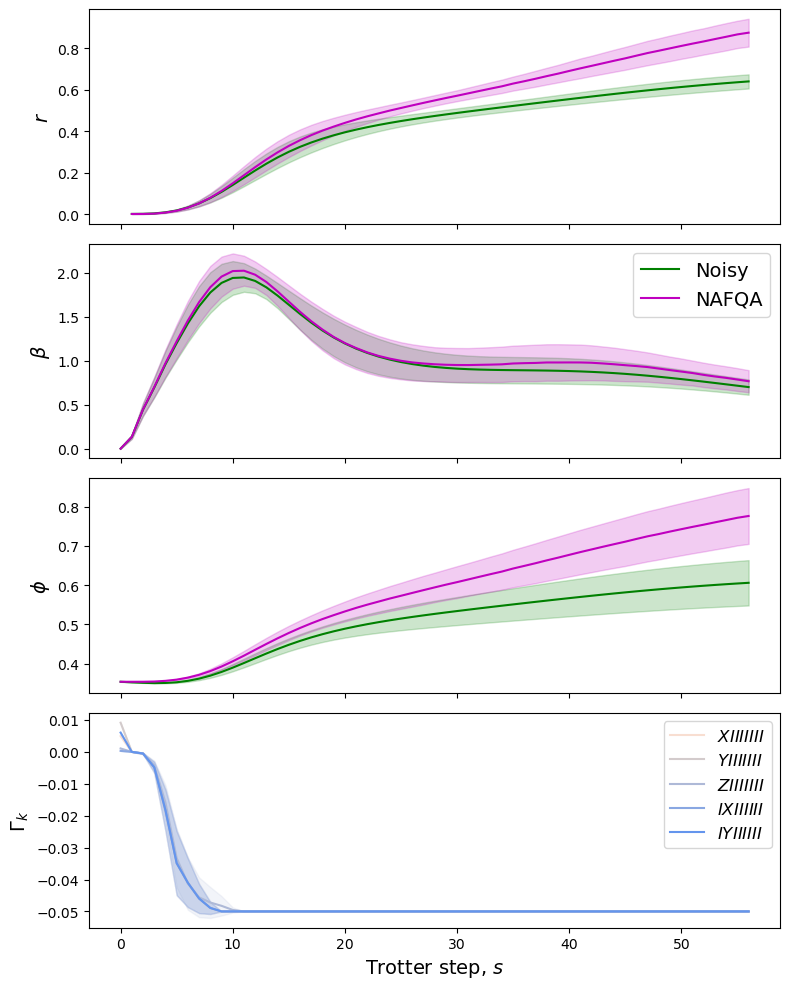

In [59]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

x = np.arange(1, len(mean_values_r_noisy)+1)
axes[0].plot(x, mean_values_r_noisy, label="Noisy", color="g")
axes[0].fill_between(x, mean_values_r_noisy - std_values_r_noisy*Norm_factor, mean_values_r_noisy + std_values_r_noisy*Norm_factor, color='g', alpha=0.2)
axes[0].plot(x, mean_values_r_naqlc, label="NA-QLC", color="m")
axes[0].fill_between(x, mean_values_r_naqlc - std_values_r_naqlc * Norm_factor, mean_values_r_naqlc + std_values_r_naqlc * Norm_factor, color='m', alpha=0.2)
# axes[0].plot([1]*26,linestyle='--', linewidth=2, color = 'black')
axes[0].set_ylabel(r"$r$", fontsize=14)
# axes[0].text(1.2, 0.77, "(a)", fontsize=12, fontweight='bold')


x = np.arange(len(mean_values_beta_noisy))
axes[1].plot(x, mean_values_beta_noisy, label="Noisy", color="g")
axes[1].fill_between(x, mean_values_beta_noisy - std_values_beta_noisy * Norm_factor, mean_values_beta_noisy + std_values_beta_noisy * Norm_factor, color='g', alpha=0.2)
axes[1].plot(x, mean_values_beta_naqlc, label="NAFQA", color="m")
axes[1].fill_between(x, mean_values_beta_naqlc - std_values_beta_naqlc * Norm_factor, mean_values_beta_naqlc + std_values_beta_naqlc * Norm_factor, color='m', alpha=0.2)
# axes[1].plot([1]*26,linestyle='--', linewidth=2, color = 'black')
axes[1].set_ylabel(r"$\beta$",fontsize=14)
# axes[1].set_xlabel(r"Trotter step, $s$", fontsize=12)
# axes[1].text(1.2, 2.25, "(b)", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=14)


x = np.arange(len(mean_values_phi_noisy))
axes[2].plot(x, mean_values_phi_noisy, label="Noisy", color="g")
axes[2].fill_between(x, mean_values_phi_noisy - std_values_phi_noisy * Norm_factor, mean_values_phi_noisy + std_values_phi_noisy * Norm_factor, color='g', alpha=0.2)
axes[2].plot(x, mean_values_phi_naqlc, label="NA-FQA", color="m")
axes[2].fill_between(x, mean_values_phi_naqlc - std_values_phi_naqlc * Norm_factor, mean_values_phi_naqlc + std_values_phi_naqlc * Norm_factor, color='m', alpha=0.2)
# axes[2].plot([1]*26,linestyle='--', linewidth=2, color = 'black')
axes[2].set_ylabel(r"$\phi$",fontsize=14)
# axes[2].set_xlabel(r"Trotter step, $s$", fontsize=14)
# axes[2].text(1.2, 0.52, "(c)", fontsize=12, fontweight='bold')


x = np.arange(len(mean_values_g0))

colors = ['#6495ED', '#89A7E2', '#AEB9D7', '#D3CBCC', '#F8DED1', '#F6BDC0']

# Plot mean with standard deviation
axes[3].plot(x, mean_values_g0, label=r"$XIIIIIII$", color=colors[4])
axes[3].fill_between(x, mean_values_g0 - std_values_g0*Norm_factor, mean_values_g0 + std_values_g0 * Norm_factor, color=colors[4], alpha=0.15)

axes[3].plot(x, mean_values_g1, label=r"$YIIIIIII$", color=colors[3])
axes[3].fill_between(x, mean_values_g1 - std_values_g1 * Norm_factor, mean_values_g1 + std_values_g1 * Norm_factor, color=colors[3], alpha=0.15)

axes[3].plot(x, mean_values_g2, label=r"$ZIIIIIII$", color=colors[2])
axes[3].fill_between(x, mean_values_g2 - std_values_g2 * Norm_factor, mean_values_g2 + std_values_g2 * Norm_factor,color=colors[2], alpha=0.15)

axes[3].plot(x, mean_values_g3, label=r"$IXIIIIII$", color=colors[1])
axes[3].fill_between(x, mean_values_g3 - std_values_g3 * Norm_factor, mean_values_g3 + std_values_g3 * Norm_factor,color=colors[1], alpha=0.15)

axes[3].plot(x[0:95], mean_values_g4[0:95], label=r"$IYIIIIII$", color=colors[0])
axes[3].fill_between(x, mean_values_g4 - std_values_g4 * Norm_factor, mean_values_g4 + std_values_g4 * Norm_factor, color=colors[0], alpha=0.15)
axes[3].legend(fontsize=12)
axes[3].set_ylabel(r"$\Gamma_k$",fontsize=14)
axes[3].set_xlabel(r"Trotter step, $s$", fontsize=14)
# axes[3].text(.8, 0.04, "(d)", fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()
# filename = f"TFIM_N8.pdf"  # Creates "plot_experiment1.png"
# plt.savefig(filename)
plt.show()


## r and phi plots

In [60]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

k = 45
seed = 3
TH = 0.05

file_path =  f'data_SG/r_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
agp_arr = np.load(file_path)
r_now_open, r_kasf1, r1_now = agp_arr[0], agp_arr[1], agp_arr[2]
r_now_open_arr.append(r_now_open)
r_kasf1_arr.append(r_kasf1)

file_path = f'data_SG/phi_N_{N}_mf_{mf}_th_{th}_dt_{dt}_ntraj_{ntraj}_seed_{seed}.npy'
agp_arr3 = np.load(file_path)
succ_prob_now_open, succ_prob_kasf1, succ_prob1_now = agp_arr3[0], agp_arr3[1], agp_arr3[2]
succ_prob_now_open_arr.append(succ_prob_now_open)
succ_prob_kasf1_arr.append(succ_prob_kasf1)


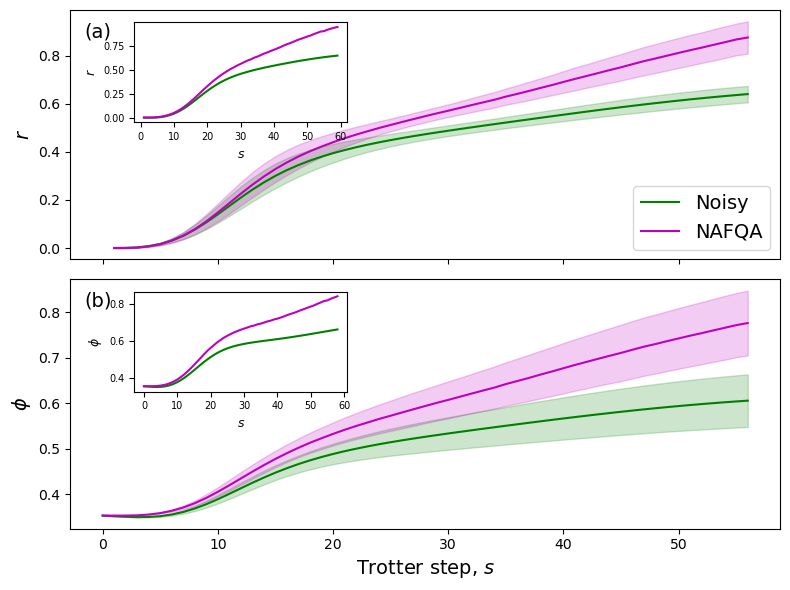

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# --- Top panel: r ---
x = np.arange(1, len(mean_values_r_noisy)+1)
axes[0].plot(x, mean_values_r_noisy, label="Noisy", color="g")
axes[0].fill_between(x, mean_values_r_noisy - std_values_r_noisy*Norm_factor, mean_values_r_noisy + std_values_r_noisy*Norm_factor, color='g', alpha=0.2)
axes[0].plot(x, mean_values_r_naqlc, label="NAFQA", color="m")
axes[0].fill_between(x, mean_values_r_naqlc - std_values_r_naqlc * Norm_factor, mean_values_r_naqlc + std_values_r_naqlc * Norm_factor, color='m', alpha=0.2)
axes[0].set_ylabel(r"$r$", fontsize=14)
axes[0].legend(fontsize=14, loc='lower right')
axes[0].text(0.02, 0.95, '(a)', transform=axes[0].transAxes, fontsize=14, va='top')

kl = 59
# seed=3 is at index 2 in seeds = [0, 1, 3, 4, 5, 8, 9, 11]
ax_inset0 = axes[0].inset_axes([0.09, 0.55, 0.30, 0.40])
x_s3 = np.arange(1, len(r_now_open[0:kl])+1)
ax_inset0.plot(x_s3, r_now_open[0:kl], color="g")
ax_inset0.plot(x_s3, r_kasf1[0:kl], color="m")
ax_inset0.set_xlabel(r"$s$", fontsize=9)
ax_inset0.set_ylabel(r"$r$", fontsize=9)
ax_inset0.tick_params(labelsize=7)

# --- Bottom panel: phi ---
x = np.arange(len(mean_values_phi_noisy))
axes[1].plot(x, mean_values_phi_noisy, label="Noisy", color="g")
axes[1].fill_between(x, mean_values_phi_noisy - std_values_phi_noisy * Norm_factor, mean_values_phi_noisy + std_values_phi_noisy * Norm_factor, color='g', alpha=0.2)
axes[1].plot(x, mean_values_phi_naqlc, label="NAFQA", color="m")
axes[1].fill_between(x, mean_values_phi_naqlc - std_values_phi_naqlc * Norm_factor, mean_values_phi_naqlc + std_values_phi_naqlc * Norm_factor, color='m', alpha=0.2)
axes[1].set_ylabel(r"$\phi$", fontsize=14)
axes[1].set_xlabel(r"Trotter step, $s$", fontsize=14)
axes[1].text(0.02, 0.95, '(b)', transform=axes[1].transAxes, fontsize=14, va='top')

ax_inset1 = axes[1].inset_axes([0.09, 0.55, 0.30, 0.40])
x_s3_phi = np.arange(len(succ_prob_now_open[0:kl]))
ax_inset1.plot(x_s3_phi, succ_prob_now_open[0:kl], color="g")
ax_inset1.plot(x_s3_phi, succ_prob_kasf1[0:kl], color="m")
ax_inset1.set_xlabel(r"$s$", fontsize=9)
ax_inset1.set_ylabel(r"$\phi$", fontsize=9)
ax_inset1.tick_params(labelsize=7)

plt.tight_layout()
filename = f"TFIM_N3_r_phi.pdf"
plt.savefig(filename)
plt.show()


In [24]:
len(r_now_open)

56

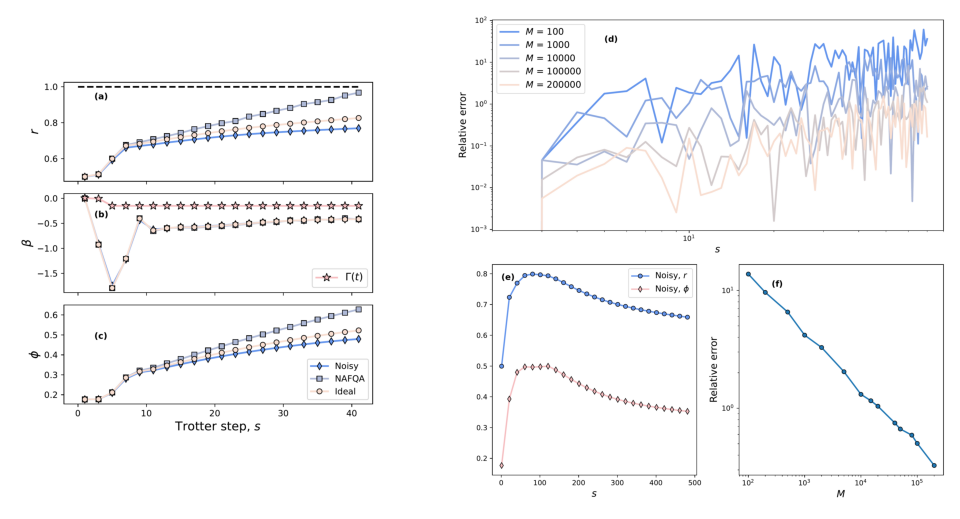

Saved → final_plots/fig2.pdf


In [3]:

# ── Compose Figure 2: Maxcut_5q (left) + large_s (right) → final_plots/fig2.pdf ──
import subprocess, os
from PIL import Image
import matplotlib.pyplot as plt

LEFT_PDF  = "final_plots/Maxcut_5q.pdf"
RIGHT_PDF = "final_plots/large_s.pdf"
OUT_PDF   = "final_plots/fig2.pdf"
DPI       = 300          # rasterisation resolution

def pdf_to_img(pdf_path, dpi=300):
    """Render the first page of a PDF to a PIL Image using pdftoppm."""
    tmp_base = pdf_path.replace(".pdf", "__tmp_render")
    subprocess.run(
        ["pdftoppm", "-r", str(dpi), "-png", "-f", "1", "-l", "1",
         pdf_path, tmp_base],
        check=True
    )
    # pdftoppm names the output {base}-1.png
    img_path = tmp_base + "-1.png"
    img = Image.open(img_path).copy()
    os.remove(img_path)
    return img

img_l = pdf_to_img(LEFT_PDF,  dpi=DPI)
img_r = pdf_to_img(RIGHT_PDF, dpi=DPI)

# Figure height fixed; panel widths preserve each image's aspect ratio
FIG_H = 5.0   # inches
w_l = (img_l.width  / img_l.height) * FIG_H
w_r = (img_r.width  / img_r.height) * FIG_H

fig, (ax_l, ax_r) = plt.subplots(
    1, 2,
    figsize=(w_l + w_r, FIG_H),
    gridspec_kw={"width_ratios": [img_l.width, img_r.width]},
)

for ax, img in [(ax_l, img_l), (ax_r, img_r)]:
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, left=0, right=1, top=1, bottom=0)
fig.savefig(OUT_PDF, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_PDF}")
